<a href="https://colab.research.google.com/github/trialdyk/marchine-learning/blob/main/JS06/Tugas1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Lab JS06 - Klasifikasi SVM pada Data `voice.csv`


## Langkah 0 - Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

RANDOM_STATE = 42
DATA_PATH = 'voice.csv'

## Langkah 1 - Load Data dan Inspeksi

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Dimensi data: {df.shape}')
df.head()

Dimensi data: (3168, 21)


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [3]:
# Cek tipe data, missing value, dan distribusi kelas
df.info()
print('\nTotal missing value:', df.isna().sum().sum())
print('\nDistribusi label:')
print(df['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

Data berisi **3.168 sampel** dengan **20 fitur akustik** numerik dan satu kolom `label` (`male` / `female`).
Tidak ada missing value dan kedua kelas seimbang, sehingga **akurasi** layak dipakai sebagai metrik.

## Langkah 2 - Pra Pengolahan Data

In [4]:
# Encode label: male = 1, female = 0
y = df['label'].map({'male': 1, 'female': 0})
X = df.drop(columns='label')

print(X.shape, y.shape)
X.describe().T[['mean', 'std', 'min', 'max']].round(4)

(3168, 20) (3168,)


,mean,std,min,max
meanfreq,0.1809,0.0299,0.0394,0.2511
sd,0.0571,0.0167,0.0184,0.1153
median,0.1856,0.0364,0.0110,0.2612
Q25,0.1405,0.0487,0.0002,0.2473
Q75,0.2248,0.0236,0.0429,0.2735
IQR,0.0843,0.0428,0.0146,0.2522
skew,3.1402,4.2405,0.1417,34.7255
kurt,36.5685,134.9287,2.0685,1309.6129
sp.ent,0.8951,0.0450,0.7387,0.9820
sfm,0.4082,0.1775,0.0369,0.8429


Rentang nilai antar fitur sangat berbeda (misalnya `kurt` dan `skew` jauh lebih besar dari `meanfreq`).
SVM sensitif terhadap skala fitur, jadi dilakukan **standardisasi** memakai `StandardScaler`.
Agar tidak terjadi *data leakage*, scaler dimasukkan ke dalam `Pipeline` sehingga hanya di-*fit* pada data latih.

## Langkah 3 - Training dan Evaluasi SVM

Eksperimen dijalankan untuk 2 rasio split x 3 kernel = **6 model**.
Split memakai `stratify=y` supaya proporsi male/female sama di data latih dan uji.

In [5]:
splits = {'70:30': 0.30, '80:20': 0.20}
kernels = ['linear', 'poly', 'rbf']

results = []
for split_name, test_size in splits.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
    )

    for kernel in kernels:
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(kernel=kernel, random_state=RANDOM_STATE)),
        ])
        model.fit(X_train, y_train)

        acc_train = accuracy_score(y_train, model.predict(X_train))
        acc_test = accuracy_score(y_test, model.predict(X_test))

        results.append({
            'Split': split_name,
            'Kernel': kernel,
            'Data Latih': len(X_train),
            'Data Uji': len(X_test),
            'Akurasi Train': acc_train,
            'Akurasi Test': acc_test,
        })

df_results = pd.DataFrame(results)
df_results

,Split,Kernel,Data Latih,Data Uji,Akurasi Train,Akurasi Test
0,70:30,linear,2217,951,0.972034,0.978970
1,70:30,poly,2217,951,0.966622,0.960042
2,70:30,rbf,2217,951,0.983762,0.983176
3,80:20,linear,2534,634,0.976717,0.974763
4,80:20,poly,2534,634,0.968035,0.955836
5,80:20,rbf,2534,634,0.983820,0.982650


## Langkah 4 - Tabulasi Performa

In [6]:
# Tabel ringkas: akurasi data uji per kernel dan split
tabel = df_results.pivot(index='Kernel', columns='Split', values='Akurasi Test').loc[kernels]
tabel_pct = tabel.mul(100).map(lambda v: f'{v:.2f} %')
tabel_pct

Split,70:30,80:20
Kernel,,
linear,97.90 %,97.48 %
poly,96.00 %,95.58 %
rbf,98.32 %,98.26 %


In [7]:
# Tabel lengkap (train vs test)
tampil = df_results.copy()
tampil['Akurasi Train'] = (tampil['Akurasi Train'] * 100).round(2)
tampil['Akurasi Test'] = (tampil['Akurasi Test'] * 100).round(2)
tampil['Selisih (Train-Test)'] = (tampil['Akurasi Train'] - tampil['Akurasi Test']).round(2)
tampil

,Split,Kernel,Data Latih,Data Uji,Akurasi Train,Akurasi Test,Selisih (Train-Test)
0,70:30,linear,2217,951,97.20,97.90,-0.70
1,70:30,poly,2217,951,96.66,96.00,0.66
2,70:30,rbf,2217,951,98.38,98.32,0.06
3,80:20,linear,2534,634,97.67,97.48,0.19
4,80:20,poly,2534,634,96.80,95.58,1.22
5,80:20,rbf,2534,634,98.38,98.26,0.12


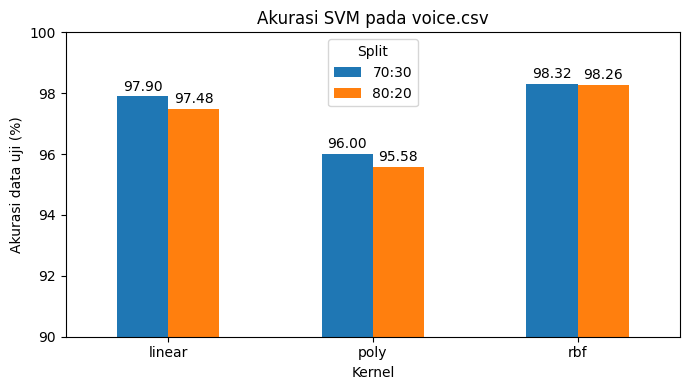

In [8]:
# Visualisasi
ax = tabel.mul(100).plot(kind='bar', figsize=(7, 4), rot=0, ylim=(90, 100))
ax.set_ylabel('Akurasi data uji (%)')
ax.set_title('Akurasi SVM pada voice.csv')
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', padding=2)
plt.tight_layout()
plt.show()

## Langkah 5 - Analisis

**Hasil akurasi data uji:**

| Kernel | 70:30 | 80:20 |
|---|---|---|
| Linear | 97,90 % | 97,48 % |
| Polynomial | 96,00 % | 95,58 % |
| RBF | 98,32 % | 98,26 % |

**Kesimpulan:**
- Kernel **RBF** paling akurat di kedua split (sekitar 98,3 %), dan selisih akurasi train-test-nya kecil, jadi tidak ada tanda overfitting yang berarti.
- Kernel **linear** hanya sedikit di bawah RBF (sekitar 97,5-97,9 %). Artinya sebagian besar pemisahan suara pria/wanita pada fitur akustik ini sudah hampir linier.
- Kernel **polynomial** (derajat 3 bawaan) paling rendah (sekitar 95,6-96,0 %). Dengan parameter bawaan kernel ini kurang cocok dibanding dua kernel lain pada data ini.
- Perbedaan antara rasio **70:30** dan **80:20** sangat kecil (di bawah 0,5 poin persen), jadi hasil tidak sensitif terhadap rasio split. Selisih sekecil ini juga masih dalam rentang variasi akibat pemilihan sampel acak.
- Catatan: hasil memakai `random_state=42` dan parameter bawaan tiap kernel (`C=1`, `degree=3`, `gamma='scale'`) tanpa tuning.